In [7]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: /opt/software-current/2023.06/x86_64/generic/software/Python/3.11.3-GCCcore-12.3.0/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

# Create Ordinary Least Squares (OLS) linear regression from scratch

What OLS does is fits the following linear equation onto a scatter of points: $$y=\beta_0+\beta_1x+\epsilon$$
Where:
- $\beta_0$ is the y-intercept
- $\beta_1$ is the slope of the line
- $\epsilon$ is the residual error
This residual can be found from: $$\epsilon=y_i-\hat{y}_i=y_i-(\beta_0+\beta_1x)$$
The goal is to find the coefficents that minimize the Sum of Squared Residuals (SSR). The residuals are squared because otherwise the negative and positive residuals would cancel $$S(\beta_0, \beta_1) = \sum^n_{i=1}\epsilon^2_i = (y_i-(\beta_0+\beta_1x))^2$$
To find the minimum of this function, we  take the partial derivatives of $S$ with respect to $\beta_0$ and $\beta_1$, set them equal to zero, and solve the system of equations. But there has to be an easier way to do this on a computer? Thankfully there is a closed form solution we can use in matrix form, where the equation looks like: $$Y=X\beta+\epsilon$$
- $Y$ is a vector of the form: $n\times 1$
- $X$ is a matrix of the form: $n\times k$ with a column of 1s added to handle the intercept
- $\beta$ is a vector of coefficients to solve for of the form: $k\times 1$
The form for the $\beta$ values is: $$\beta=(X^TX)^{-1}X^TY$$

In [3]:
# finding beta vector
def OLS(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

# making X and Y suitable for OLS
def construct_XY(x,y):
    X = np.column_stack((np.ones(len(x)), x))
    Y = np.asarray(y)
    return X, Y

# find y_pred
def make_preds(X, beta):
    return X @ beta

But how can we check how well our regressor is doing? We can use bias, variance, and $R^2$ score
- Bias measures how far off a model's average predictions are from the true values. In other words, it measures how much a model tends to oversimplify or underfit.
- Variance measures how much the predictions fluctuate based on different training data. In other words, it measures how sensitive the model is, or overfitting.
- $R^2$ score is a metric that represents the proportion of variance in the target variable that can be explained by the model. If this value is too high on training data it can mean overfitting
- F-statistic: The F-statistic tests the global null hypothesis that all your regression coefficients are equal to zero. Basically, how much better is the fit than a straight line

You'll notice that it will take more than one dataset to compute these, so to implement bias and variance, we can use a Monte Carlo simulation. We need to test multiple datasets to do this, so we can slightly randomize the data (add noise) to the data every simulation to determine these values

In [4]:
def R_2(y_true, y_pred):
    # sum of residuals
    ss_res = np.sum((y_true - y_pred) ** 2)

    # sum of squares
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res/ss_tot)

def F_stat(y_true, y_pred, p):
    n = len(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_reg = ss_tot - ss_res
    
    df_reg = p
    df_res = n - p - 1
    
    numerator = ss_reg / df_reg
    denominator = ss_res / df_res
    
    return numerator / denominator
def LL(y_true, y_pred):
    n = len(y_true)
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    sigma_sq_mle = ss_res / n
    
    term1 = - (n / 2) * np.log(2 * np.pi)
    term2 = - (n / 2) * np.log(sigma_sq_mle)
    term3 = - (n / 2)
    
    return term1 + term2 + term3

In [5]:
# Test + Monte Carlo bias + variance calculation

rng = np.random.default_rng(42)

x = np.linspace(0, 30, 20)
true_slope, true_int = 7, 9
y = lambda xi: true_slope*xi + true_int

n_sims = 100
noise_range = 2
all_preds = np.zeros((n_sims, len(x)))

# do fit testing
for i in range(n_sims):
    noise = rng.uniform(low=-noise_range, high=noise_range, size=x.shape)
    noisy_data = y(x) + noise

    X, Y = construct_XY(x, noisy_data)
    beta = OLS(X, Y)

    all_preds[i] = make_preds(X, beta)

y_true = y(x)

mean_pred = all_preds.mean(axis=0)
bias_sq = (mean_pred - y_true) ** 2
variance = all_preds.var(axis=0)
R2 = R_2(y_true, mean_pred)
F_s = F_stat(y_true, mean_pred, 1)
LL_ = LL(y_true, mean_pred)
mse = np.mean((all_preds - y_true) ** 2, axis=0)

print(f"Variance: {variance}")
print(f"Bias (squared): {bias_sq}")
print(f"MSE: {mse}")
print(f"R^2 value: {R2}")
print(f"F statistic: {F_s}")
print(f"Log Likelihood: {LL_}")

Variance: [0.2890216  0.24371736 0.20322219 0.16753611 0.1366591  0.11059118
 0.08933233 0.07288257 0.06124189 0.05441029 0.05238776 0.05517432
 0.06276996 0.07517468 0.09238848 0.11441136 0.14124332 0.17288436
 0.20933448 0.25059368]
Bias (squared): [8.01391093e-04 5.82477223e-04 3.98412696e-04 2.49197512e-04
 1.34831671e-04 5.53151729e-05 1.06480183e-05 8.30206752e-07
 2.58617384e-05 8.57426131e-05 1.80472831e-04 3.10052392e-04
 4.74481296e-04 6.73759544e-04 9.07887134e-04 1.17686407e-03
 1.48069034e-03 1.81936596e-03 2.19289093e-03 2.60126523e-03]
MSE: [0.28982299 0.24429983 0.2036206  0.1677853  0.13679393 0.11064649
 0.08934298 0.0728834  0.06126775 0.05449603 0.05256824 0.05548437
 0.06324444 0.07584844 0.09329637 0.11558822 0.14272401 0.17470373
 0.21152737 0.25319495]
R^2 value: 0.9999998256648424
F statistic: 103249379.54181278
Log Likelihood: 44.1501726033284


In [15]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 34.0 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 25.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [8]:
# Compare with statsmodels
import statsmodels.api as sm

df = pd.DataFrame({'x': x, 'y': y(x)})
X_with_constant = sm.add_constant(df['x'])
model = sm.OLS(df['y'], X_with_constant)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.244e+32
Date:                Fri, 12 Jun 2026   Prob (F-statistic):          8.24e-284
Time:                        10:51:17   Log-Likelihood:                 610.91
No. Observations:                  20   AIC:                            -1218.
Df Residuals:                      18   BIC:                            -1216.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.0000   5.96e-15   1.51e+15      0.0

# Polynomial Regression

You liked OLS regression? Imagine if we had higher order coefficents to fit other types of data? Similarly to linear regression the equation up to the $n$th polynomial is structured like this: $$y = \beta_0+\beta_1x_1+\beta_2x^2_2...+\beta_n x^{n}_n + \epsilon$$
You might be asking, why would something that makes polynomials still be called linear? The term "linear" doesn't refer to the geometric shape of the resulting curve; it refers to how the parameters ($\beta$) enter the equation. The model is linear in its coefficients, as in not being raised to any powers.

This process works very similarly to OLS except there is an added "feature expansion" stage where if your data has a $3$ as an entry, the feature expansion would convert that into $[3, 9, 27, ...]$ so the $X$ matrix looks like: $$X = \begin{pmatrix}x_1 & x_1^2 & ... & x_1^n\\x_2 & x_2^2 & ... & x_2^n\\...\\x_n & x_n^2 & ... & x_n^n\end{pmatrix}$$

In [9]:
# finding beta vector
def Linear(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y

# making X and Y suitable for OLS
def construct_XY(x, y, deg):
    X = np.ones((len(x), deg))
    for i in range(len(x)):
        for j in range(1, deg):
            X[i,j] = x[i]**j
                
    Y = np.asarray(y)
    return X, Y

# find y_pred
def make_preds(X, beta):
    return X @ beta

In [60]:
beta0, beta1, beta2, beta3 = 3, 4, 7, 4

y_4 = lambda xi: beta0 + beta1*(xi**2) + beta2*(xi**3) + beta3*(xi**4)

x = np.linspace(-30, 30, 30)

noise_range = 2
noise = np.random.normal(0.0, noise_range, size=x.shape)

noisy_y = y_4(x) + noise

noise = np.random.normal(0.0, noise_range, size=x.shape)
noisy_x = x + noise


deg = 5   # [1,x,x^2,x^3,x^4]

X, Y = construct_XY(noisy_x, noisy_y, deg)

beta = Linear(X, Y)

y_pred = make_preds(X, beta)

print(beta)

[-6.51441500e+04 -4.20743128e+03  1.20534120e+03  2.41289138e+01
  2.66551603e+00]


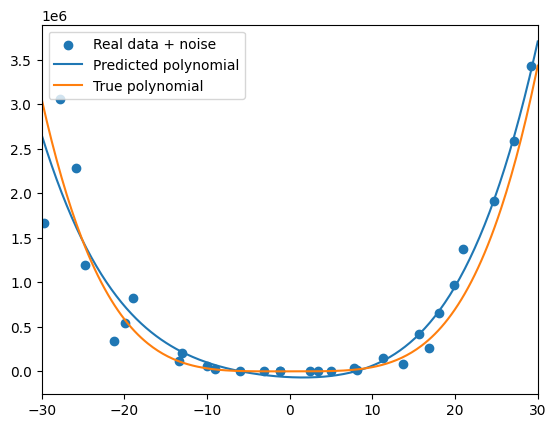

In [61]:
# smooth x values for plotting
x_plot = np.linspace(-30, 30, 300)

# make design matrix for x_plot
X_plot, _ = construct_XY(x_plot, x_plot, deg)

# predictions on smooth curve
y_plot = make_preds(X_plot, beta)


plt.xlim(-30, 30)

plt.scatter(noisy_x, noisy_y, label="Real data + noise")
plt.plot(x_plot, y_plot, label="Predicted polynomial")
plt.plot(x_plot, y_4(x_plot), label="True polynomial")

plt.legend()
plt.show()

# Logistic Regression from Scratch
Logistic regression is special because it can be used for binary classification. It is probabily one of the most important and simple ML models. But let's get a little more into depth here. The structure is essentially: $$\text{Input}\rightarrow\text{Linear regression style fit}\rightarrow\text{Activation function}\rightarrow\text{Probability of class }1\text{ or }0$$
Seems simple, right? Nope, sorry, now I have to do a long writeup explaining the basics of ML and Deep Learning.
## Linear regression style fit
Just like linear regression, the model first computes a weighted sum of the input features plus the intercept (or more commonly known as bias): $$z=\beta_0+\beta_1x_1+\beta_2x_2+...+\beta_nx_n$$
Where:
- $x_1, x_2, ...$ represent the input features
- $\beta_1, \beta_2, ...$ represent the coefficents (more commonly known as weights)
## Activation function
The values that come from $z$ can range from $-\infty$ to $\infty$ which isn't super helpful since we need the probability of if it is one class or another. So we can use an activation function to normalize this result on the range of $0$ to $1$. The Sigmoid activation function can do exactly this $$\sigma(z)=\frac{1}{1+\exp(-z)}$$
## Gradient Decent
You'll notice that there's no residual error in the fit function. That is because we use Gradient Descent to minimize the loss, which is a form of error (will discuss later). Gradient Descent is literally used to take successive steps in the direction of steepest descent to find the lowest point of a function. Imagine you are a kid with a sled and you want to find the steepest part of the hill so you can beat your friends/family to the bottom, same concept basically. 

To update a specific weight we need to know how the total loss changes with respect to that weight. This requires calculating the partial derivative $\frac{\partial J(\theta)}{\partial \theta_j}$ using the Chain Rule. What we do next is called backpropigation, it represents the process of calculating the gradients for gradient descent to use later on. First we feedforward (run through the model as is) and then calculate the derivatives to update the weights and biases. Mathematically: $$\frac{\partial J(w)}{\partial w}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_j}$$
Where:
- $J$ is the loss function, the derivative is in terms of the true $y$ values
- $\hat{y}$ is the predicted $y$ value which can be represented as: $\sigma(z)$
- $z$ is the output of the linear fit

Lets do the derivatives! 
### Sigmoid Derivative
Lets start with the sigmoid derivative: It is easier to think of this as $\hat{y} = \sigma(z) = (1 + e^{-z})^{-1}$ first: $$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot \frac{d}{dz}(1 + e^{-z})$$$$\frac{\partial \hat{y}}{\partial z} = -1(1 + e^{-z})^{-2} \cdot (e^{-z} \cdot -1)$$The negatives cancel out:$$\frac{\partial \hat{y}}{\partial z} = \frac{e^{-z}}{(1 + e^{-z})^2}$$Now, we can rewrite this fraction strategically by splitting the denominator:$$\frac{\partial \hat{y}}{\partial z} = \left( \frac{1}{1 + e^{-z}} \right) \cdot \left( \frac{e^{-z}}{1 + e^{-z}} \right)$$Notice that the first term is exactly $\hat{y}$. For the second term, we can add and subtract $1$ in the numerator:$$\frac{e^{-z}}{1 + e^{-z}} = \frac{1 + e^{-z} - 1}{1 + e^{-z}} = \frac{1 + e^{-z}}{1 + e^{-z}} - \frac{1}{1 + e^{-z}} = 1 - \hat{y}$$Substituting these back in gives us the classic property of the sigmoid derivative:$$\frac{\partial \hat{y}}{\partial z} = \hat{y}(1 - \hat{y})$$
### Loss Function derivative
Spoilers, we are using cross entropy loss. I will go over why we chose it in the next section. We take the derivative of $L = -y \ln(\hat{y}) - (1 - y) \ln(1 - \hat{y})$ with respect to $\hat{y}$. Recall that $\frac{d}{dx}(\ln x) = \frac{1}{x}$.$$\frac{\partial L}{\partial \hat{y}} = - \left[ y \cdot \frac{1}{\hat{y}} + (1 - y) \cdot \frac{1}{1 - \hat{y}} \cdot (-1) \right]$$The $(-1)$ comes from the chain rule applied to the inner term $(1 - \hat{y})$. Simplifying the signs:$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1 - y}{1 - \hat{y}}$$Now, let's find a common denominator to combine these fractions:$$\frac{\partial L}{\partial \hat{y}} = \frac{-y(1 - \hat{y}) + \hat{y}(1 - y)}{\hat{y}(1 - \hat{y})}$$$$\frac{\partial L}{\partial \hat{y}} = \frac{-y + y\hat{y} + \hat{y} - y\hat{y}}{\hat{y}(1 - \hat{y})}$$The $y\hat{y}$ terms cancel perfectly, leaving:$$\frac{\partial L}{\partial \hat{y}} = \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})}$$
### Derivative of the Linear term
This is the easiest step. We look at the linear sum and differentiate with respect to the specific weight $\theta_j$:$$z = \theta_0 x_0 + \theta_1 x_1 + \dots + \theta_j x_j + \dots + \theta_n x_n$$Since all other terms are treated as constants relative to $\theta_j$, their derivatives are $0$:$$\frac{\partial z}{\partial \theta_j} = x_j$$

### Put it all together
Now we multiply our three pieces back together:$$\frac{\partial L}{\partial \theta_j} = \left[ \frac{\hat{y} - y}{\hat{y}(1 - \hat{y})} \right] \cdot \Big[ \hat{y}(1 - \hat{y}) \Big] \cdot \big[ x_j \big]$$
Which nicely reduces to: $$\frac{\partial L}{\partial \theta_j} = (\hat{y} - y) \cdot x_j$$

We can define our weight update as: $$\theta_{new}=\theta - \alpha(\hat{y} - y) \cdot x_j$$
Where:
- $\alpha$ represents the step size of the optimization which is also called the learning rate
## Loss
Ok so you already know we are using the cross entropy loss. We use this instead of the more popular mean squared error because it is better at handling nonlinear activation functions. If you use MSE with the sigmoid function, the cost function becomes non-convex (wavy with multiple "valleys"). This makes it extremely difficult for gradient descent to find the absolute lowest error. Cross-entropy results in a strictly convex curve, guaranteeing a single global minimum. See one of the cells below which demonstrates my point. But why don't we use a linear activation function? This is because of backpropigation, if you do the derivative on a linear function you get a constant, also the output would be out of bounds for the probability we need.

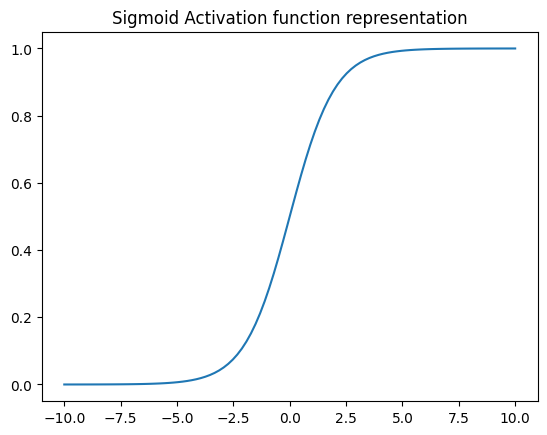

In [18]:
# Sigmoid Activation function

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

x = np.linspace(-10, 10, 100)

plt.title("Sigmoid Activation function representation")
plt.plot(x, sigmoid(x))

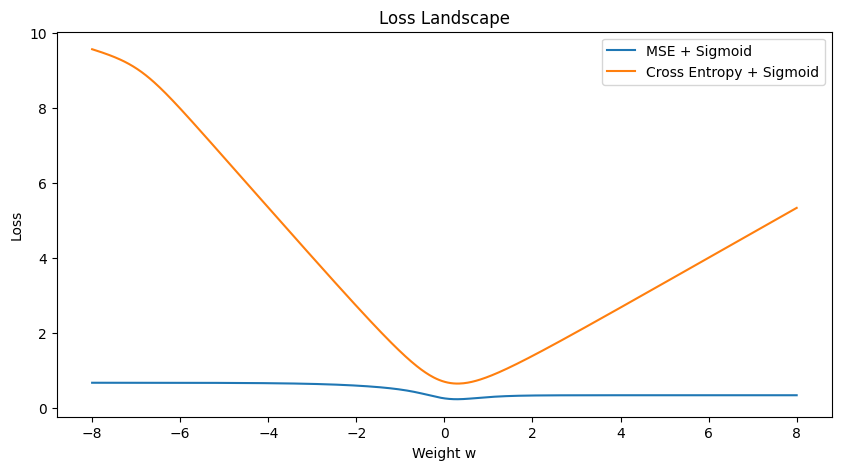

In [31]:
x = np.array([-3,-2,-1,1,2,3])
y = np.array([0,1,0,1,0,1])

def mse_loss(w):
    preds = sigmoid(w*x)
    return np.mean((preds-y)**2)


def bce_loss(w):
    preds = sigmoid(w*x)
    eps = 1e-9
    return -np.mean(y*np.log(preds+eps) + (1-y)*np.log(1-preds+eps))

weights = np.linspace(-8,8,500)

mse = [mse_loss(w) for w in weights]
bce = [bce_loss(w) for w in weights]

plt.figure(figsize=(10,5))

plt.plot(weights,mse,label="MSE + Sigmoid")
plt.plot(weights,bce,label="Cross Entropy + Sigmoid")

plt.xlabel("Weight w")
plt.ylabel("Loss")
plt.title("Loss Landscape")
plt.legend()

plt.show()

In [20]:
# Logistic Regression implementation

class LogReg:
    def __init__(self, lr, epoches):
        self.lr = lr
        self.epoches = epoches   # an epoch represents the amount of times fit loop (backprop+GD) occurs
        self.w = None
        self.bias = 0
        self.loss = []

    def binary_cross_e(self, y_true, y_pred):
        m = len(y_true)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)   # Clip values to avoid log(0) numeric instability
        return -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))   # this 1/m term comes from the fact that we are using the form of binary cross entropy that is for multiple observations

    def return_loss(self):
        return self.loss

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        
        for i in range(self.epoches):
            # feed forward
            z = np.dot(X, self.w) + self.bias
            h = sigmoid(z)

            # backprop
            dw = (1 / n_samples) * np.dot(X.T, (h - y))
            db = (1 / n_samples) * np.sum(h - y)

            # updating weights + bias
            self.w -= dw * self.lr
            self.bias -= db * self.lr

            self.loss.append(self.binary_cross_e(y, h))

    def predict(self, X):
        z = np.dot(X, self.w) + self.bias
        return (sigmoid(z) >= 0.5).astype(int)

## Basics of training a model

When you train something like this you need data to train on obviously, but you also need to validate that it actually works. How this is typically done is splitting the dataset into a training and validation/test set. If you test on data you trained on you are risking overfitting and having an idea of how well it would work in the real world. A recommended train test split is 80/20 train/test split. We can see how well a model is actually learning by looking at a loss plot, which represents the loss value over the epoches. This plot ideally looks like exponential decrease.

Text(0, 0.5, 'Loss')

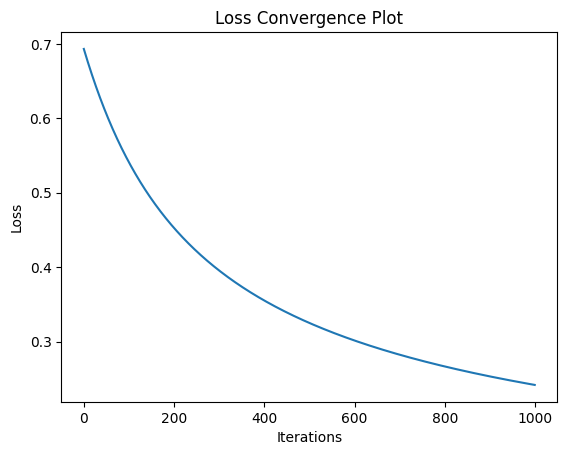

In [30]:
# Now for actually testing

dataset = datasets.load_breast_cancer()   # load an actual dataset
X, y = dataset.data, dataset.target

# Standardize features to have mean=0 and variance=1, helps the model converge easier
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=1234
)

model = LogReg(lr = 0.001, epoches = 1000)
model.fit(X_train, y_train)
loss = model.return_loss()
plt.plot(loss)
plt.title("Loss Convergence Plot")
plt.xlabel("Iterations")
plt.ylabel("Loss")

## Basics of validation matrics
Cool, but now how do we know how well our model does on the validation data? This varries from model to model, but since this is classification, we need a confusion matrix to see how well the model performs for each class. The diagonals are the # of correct predictions per class and plots the actual ground-truth labels along one axis (usually rows) and the predicted labels along the other axis (usually columns).

In [39]:
# Making predictions
y_preds = model.predict(X_test)

# Raw accuracy percent
accuracy = np.mean(y_preds == y_test)
print(f"Model Accuracy: {accuracy:.2f}")

cm = confusion_matrix(np.array(y_test), np.array(y_preds))
print(f"Confusion Matrix:\n{cm}")

Model Accuracy: 0.89
Confusion Matrix:
[[36  9]
 [ 3 66]]
